# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is an **unsupervised dimensionality reduction technique**.

PCA transforms a dataset with many features into a smaller number of new features called **Principal Components**.

The main goal of PCA is to reduce the number of dimensions while preserving as much important information (variance) as possible.

### Example

Suppose our dataset has:

```text
10 Features
    ↓
   PCA
    ↓
2 Principal Components

In [46]:
import seaborn as sns
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [47]:
df.shape

(344, 7)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [49]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [50]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features].dropna()

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

In [52]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=4
)

X_pca = pca.fit_transform(
    X_scaled
)

X_pca.shape

(342, 4)

In [53]:
X_pca[:5]

array([[-1.84344489,  0.04770222, -0.23279416, -0.52390297],
       [-1.30676189, -0.42834824, -0.02956235, -0.40242643],
       [-1.36918099, -0.1544764 ,  0.1986723 ,  0.52800677],
       [-1.87882665, -0.00204841, -0.61859624,  0.47837837],
       [-1.91174773,  0.8292096 , -0.68658406,  0.20742762]])

In [54]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.68843878, 0.19312919, 0.09130898, 0.02712305])

In [55]:
explained_variance_percentage = (
    explained_variance * 100
)

explained_variance_percentage

array([68.8438781 , 19.31291885,  9.13089766,  2.7123054 ])

In [56]:
for i, variance in enumerate(
    explained_variance_percentage,
    start=1
):
    
    print(
        f"PC{i}: {variance:.2f}%"
    )

PC1: 68.84%
PC2: 19.31%
PC3: 9.13%
PC4: 2.71%


In [57]:
import numpy as np
cumulative_variance = np.cumsum(
    explained_variance
)

cumulative_variance

array([0.68843878, 0.88156797, 0.97287695, 1.        ])

In [58]:
for i, variance in enumerate(
    cumulative_variance * 100,
    start=1
):
    
    print(
        f"First {i} Components: "
        f"{variance:.2f}%"
    )

First 1 Components: 68.84%
First 2 Components: 88.16%
First 3 Components: 97.29%
First 4 Components: 100.00%


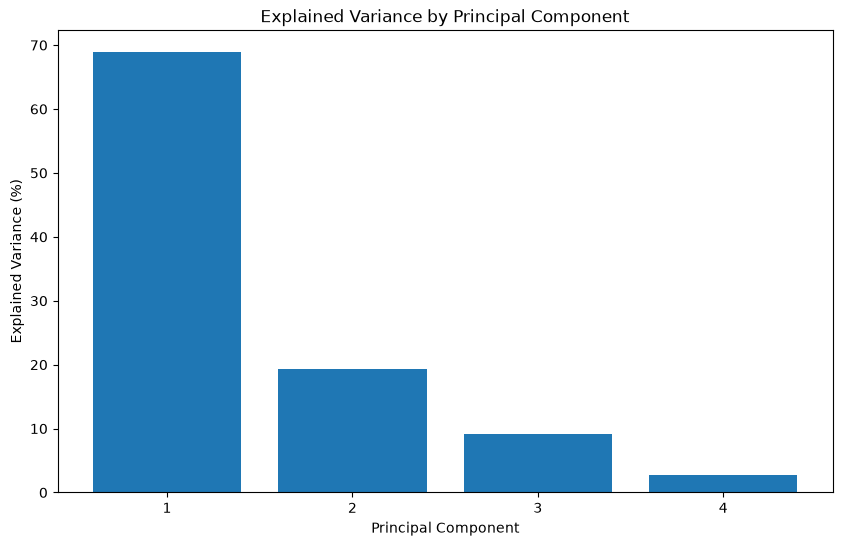

In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.bar(
    range(1, 5),
    explained_variance_percentage
)

plt.title(
    "Explained Variance by Principal Component"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Explained Variance (%)"
)

plt.xticks(
    range(1, 5)
)

plt.show()

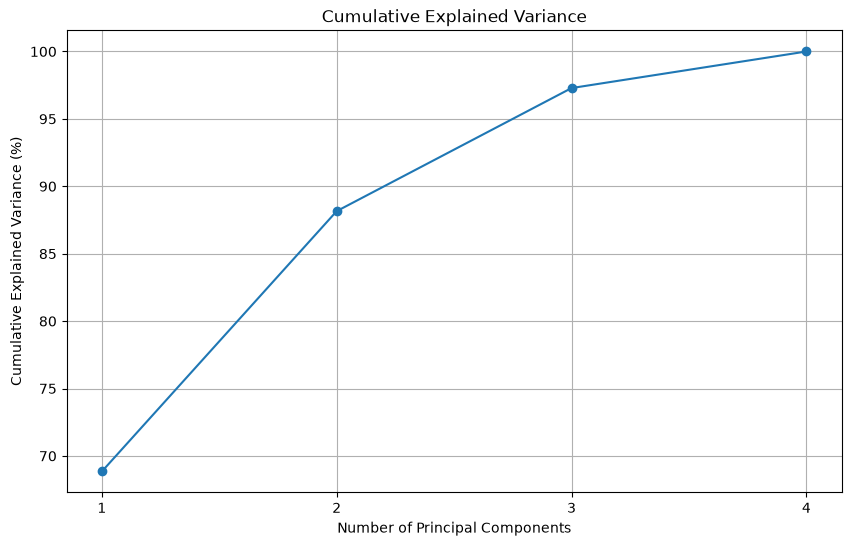

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 5),
    cumulative_variance * 100,
    marker="o"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.xticks(
    range(1, 5)
)

plt.grid()

plt.show()

In [61]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components required for 95% variance:",
    n_components_95
)

Components required for 95% variance: 3


In [62]:
pca_2 = PCA(
    n_components=2
)

X_pca_2 = pca_2.fit_transform(
    X_scaled
)

X_pca_2.shape

(342, 2)

In [63]:
import pandas as pd 
pca_df = pd.DataFrame(
    X_pca_2,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df.head()

,PC1,PC2
0,-1.843445,0.047702
1,-1.306762,-0.428348
2,-1.369181,-0.154476
3,-1.878827,-0.002048
4,-1.911748,0.829210


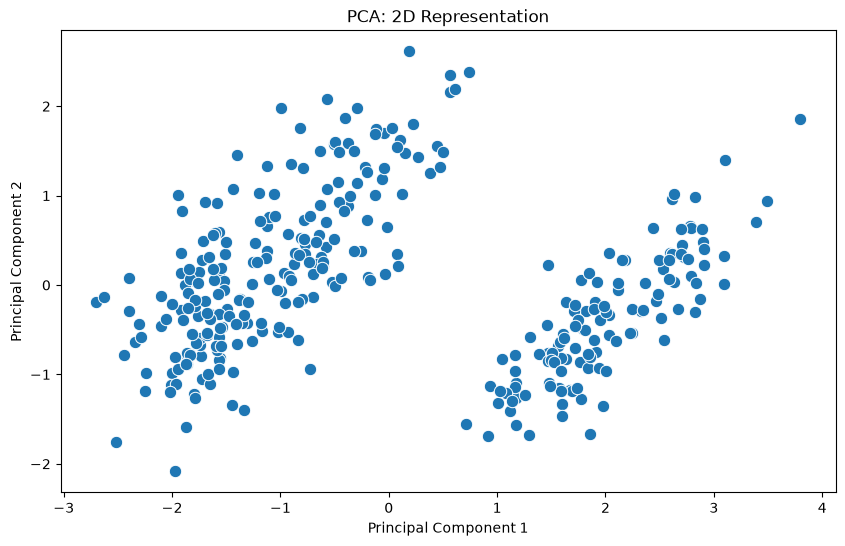

In [64]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    s=80
)

plt.title(
    "PCA: 2D Representation"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()

In [65]:
pca_plot = pca_df.copy()

pca_plot["species"] = df.loc[
    X.index,
    "species"
].values

pca_plot.head()

,PC1,PC2,species
0,-1.843445,0.047702,Adelie
1,-1.306762,-0.428348,Adelie
2,-1.369181,-0.154476,Adelie
3,-1.878827,-0.002048,Adelie
4,-1.911748,0.829210,Adelie


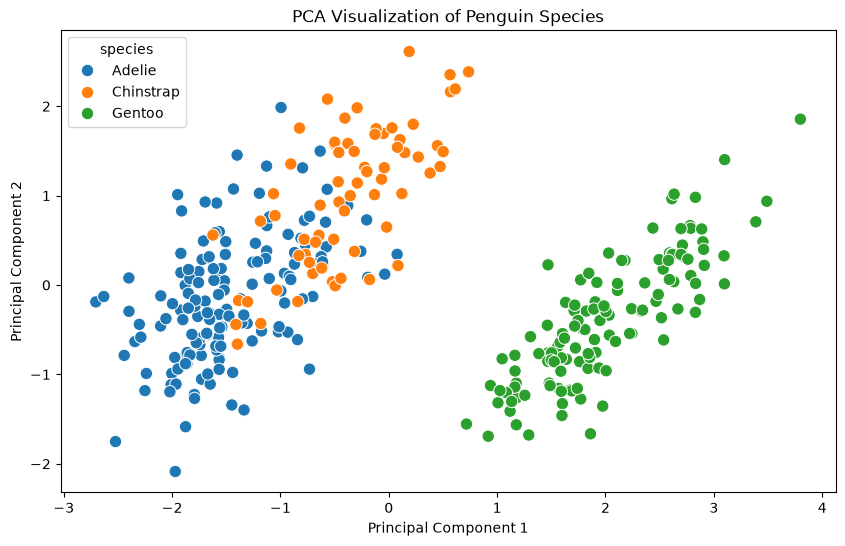

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="species",
    s=80
)

plt.title(
    "PCA Visualization of Penguin Species"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.show()